# Closed-Ring Negative Visualization

Overlays the tile-level **closed** ring negatives on the (hand-cleaned) **eroded** inklabels.
Matches the training path exactly: base = eroded (no original source), `CLOSE_R=3`, `GAP_R=6`,
fixed `ring_shell_r=1`, tile = 16px.

- GREEN  = positive tiles (eroded ink)
- YELLOW = ring negatives (fixed 1-tile shell, 6-tile / 96px air gap from ink)
- GRAY   = exclusion zone (closed ink + air gap; not trained on)


In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches

scroll = '20240304141531'
T = 16
# closed-ring params — must match utils/config.py / dataloader
CLOSE_R, GAP_R, SHELL_R = 3, 3, 2

# load ONLY the (hand-cleaned) eroded labels + mask. no original inklabels source.
eroded = cv2.imread(f'../eroded2_inklabels/{scroll}.png', cv2.IMREAD_GRAYSCALE) / 255.0
mask   = cv2.imread(f'../masks/{scroll}.png',            cv2.IMREAD_GRAYSCALE) / 255.0

h = min(eroded.shape[0], mask.shape[0])
w = min(eroded.shape[1], mask.shape[1])
eroded = eroded[:h, :w]
mask   = mask[:h, :w]
n_ty, n_tx = h // T, w // T
print(f'eroded {eroded.shape}  mask {mask.shape}  tiles {n_ty}x{n_tx}  tile={T}px')


eroded (6400, 7980)  mask (6400, 7980)  tiles 400x498  tile=16px


In [23]:
# tile-level maps: positives (eroded ink) and mask coverage
ink_tile  = np.zeros((n_ty, n_tx), np.uint8)
mask_tile = np.zeros((n_ty, n_tx), np.uint8)
for ty in range(n_ty):
    for tx in range(n_tx):
        if np.any(eroded[ty*T:(ty+1)*T, tx*T:(tx+1)*T] > 0.5): ink_tile[ty, tx] = 1
        if np.any(mask[  ty*T:(ty+1)*T, tx*T:(tx+1)*T] > 0.5): mask_tile[ty, tx] = 1

def build_closed_ring(ink_tile, mask_tile, close_r, gap_r, shell_r):
    """closed ring off eroded ink: close holes -> air gap -> fixed shell. matches dataloader."""
    rect = lambda r: cv2.getStructuringElement(cv2.MORPH_RECT, (2*r+1, 2*r+1))
    excl = ink_tile.copy()
    if close_r > 0:
        excl = cv2.erode(cv2.dilate(excl, rect(close_r)), rect(close_r)) & mask_tile
    if gap_r > 0:
        excl = cv2.dilate(excl, rect(gap_r)) & mask_tile          # ink + air gap = exclusion zone
    ring = ((cv2.dilate(excl, rect(shell_r)) - excl) > 0) & (mask_tile > 0)
    return excl, ring

exclusion, ring = build_closed_ring(ink_tile, mask_tile, CLOSE_R, GAP_R, SHELL_R)

pos_n, ring_n = int(ink_tile.sum()), int(ring.sum())
contam = int((ring & (ink_tile > 0)).sum())   # ring tiles containing eroded ink — 0 by construction
print(f'positives(eroded)={pos_n}  ring_negatives={ring_n}  ratio={ring_n/max(pos_n,1):.2f}')
print(f'contamination={contam}  gap={GAP_R*T}px  shell={SHELL_R*T}px')


positives(eroded)=1924  ring_negatives=3207  ratio=1.67
contamination=0  gap=48px  shell=32px


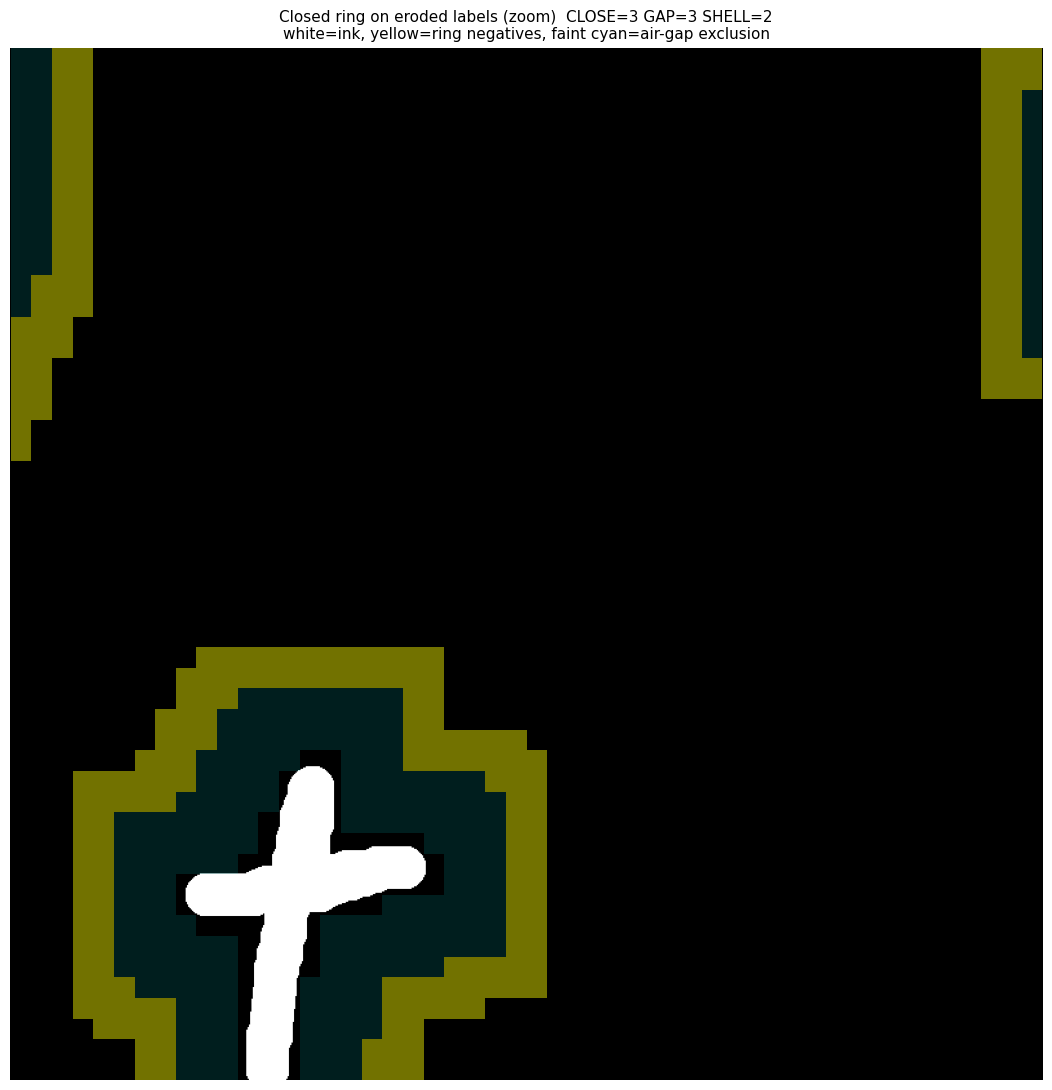

In [24]:
# zoomed overlay: closed ring on the eroded label image, centered on the ink
ys, xs = np.where(ink_tile > 0)
cy, cx = int(ys.mean()), int(xs.mean())
y0, y1 = max(0, cy-25), min(n_ty, cy+25)
x0, x1 = max(0, cx-25), min(n_tx, cx+25)

fig, ax = plt.subplots(figsize=(11, 11))
ax.imshow(eroded[y0*T:y1*T, x0*T:x1*T], cmap='gray', vmin=0, vmax=1)
for ty in range(y0, y1):
    for tx in range(x0, x1):
        py, px = (tx-x0)*T, (ty-y0)*T   # note: (col, row) for Rectangle xy
        if ring[ty, tx]:
            ax.add_patch(plt.Rectangle((py, px), T, T, lw=0, facecolor='yellow', alpha=0.45))
        elif exclusion[ty, tx] and not ink_tile[ty, tx]:
            ax.add_patch(plt.Rectangle((py, px), T, T, lw=0, facecolor='cyan', alpha=0.12))
ax.set_title(f'Closed ring on eroded labels (zoom)  CLOSE={CLOSE_R} GAP={GAP_R} SHELL={SHELL_R}\n'
             f'white=ink, yellow=ring negatives, faint cyan=air-gap exclusion', fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()


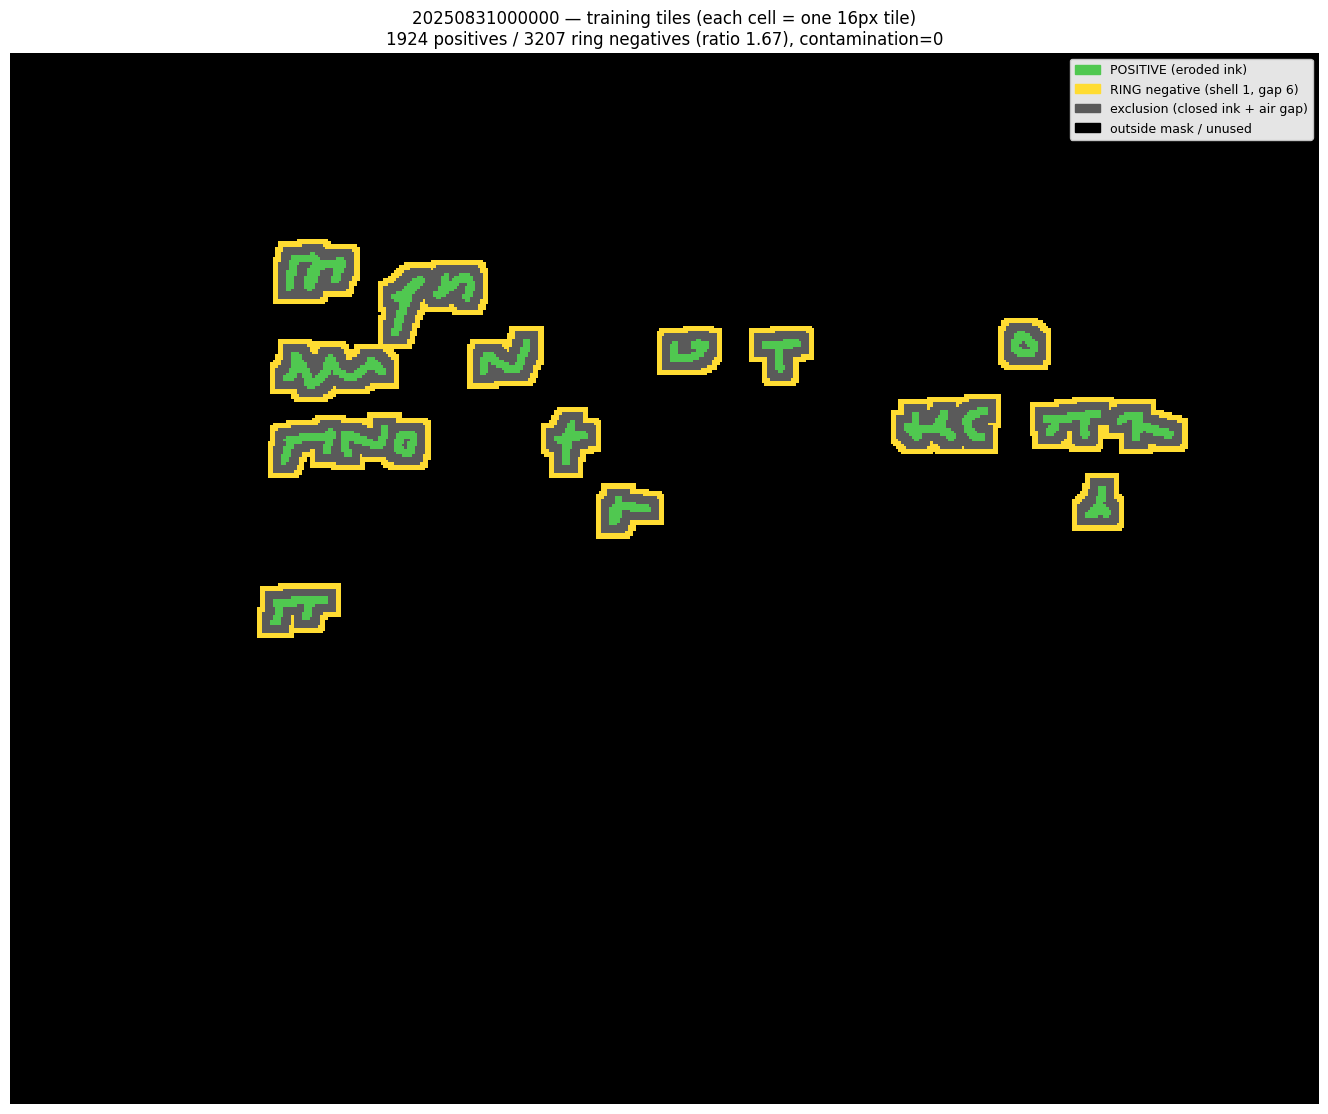

In [25]:
# full-scroll view of exactly what the model trains on (one cell = one 16px tile)
img = np.zeros((n_ty, n_tx, 3), np.uint8)
img[exclusion > 0] = [90, 90, 90]     # exclusion (closed ink + air gap)
img[ring > 0]      = [255, 220, 50]   # ring negatives (disjoint from exclusion)
img[ink_tile > 0]  = [80, 200, 80]    # positives, drawn last so they sit on top

fig, ax = plt.subplots(figsize=(14, max(3, 14 * n_ty / n_tx)))
ax.imshow(img, interpolation='nearest')   # default aspect='equal' -> no distortion
ax.set_title(f'{scroll} — training tiles (each cell = one {T}px tile)\n'
             f'{pos_n} positives / {ring_n} ring negatives '
             f'(ratio {ring_n/max(pos_n,1):.2f}), contamination={contam}', fontsize=12)
ax.axis('off')
patches = [
    mpatches.Patch(color=[80/255, 200/255, 80/255],  label='POSITIVE (eroded ink)'),
    mpatches.Patch(color=[255/255, 220/255, 50/255], label='RING negative (shell 1, gap 6)'),
    mpatches.Patch(color=[90/255, 90/255, 90/255],   label='exclusion (closed ink + air gap)'),
    mpatches.Patch(color=[0, 0, 0],                  label='outside mask / unused'),
]
ax.legend(handles=patches, loc='upper right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()
